# HW08-09 – PyTorch MLP: регуляризация и оптимизация обучения

## Импорты, seed и устройство

In [39]:
import os
import math
import time
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

import pandas as pd
import json

# Повторяемость
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## Данные и DataLoader

In [9]:
from torch.utils.data import DataLoader, TensorDataset, random_split
import torchvision
from torchvision import datasets, transforms

data_dir = "./data"
val_fraction = 0.15
batch_size = 128
num_workers = 0

# определение transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
])

# загрузка датасета CIFAR10
train_ds = datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)
test_ds  = datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform)

# разбиение train/val
val_size = int(len(train_ds) * val_fraction)
train_size = len(train_ds) - val_size

generator = torch.Generator().manual_seed(SEED)
train_split, val_split = random_split(train_ds, [train_size, val_size], generator=generator)

# Dataloader для train/val/test
train_loader = DataLoader(train_split, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_split, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())

# sanity-check
print(f"\nДатасет: CIFAR10")
num_classes = len(train_ds.classes)
class_names = train_ds.classes
print(f"Количество классов: {num_classes}")
print(f"Классы: {class_names}")
print(f"Размеры: train={len(train_split)}, val={len(val_split)}, test={len(test_ds)}")
print("Количество батчей | train:", len(train_loader), "| val:", len(val_loader), "| test:", len(test_loader))
images, labels = next(iter(train_loader))
input_dim = images.shape[1] * images.shape[2] * images.shape[3]
print(f"Форма батча изображений (x.shape): {images.shape}")
print(f"Форма батча меток (y.shape): {labels.shape}")
print(f"Диапазон значений изображений: [{images.min():.3f}, {images.max():.3f}]")
print(f"Ожидаемый диапазон после Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)): [-1, 1]")


Датасет: CIFAR10
Количество классов: 10
Классы: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Размеры: train=42500, val=7500, test=10000
Количество батчей | train: 333 | val: 59 | test: 79
Форма батча изображений (x.shape): torch.Size([128, 3, 32, 32])
Форма батча меток (y.shape): torch.Size([128])
Диапазон значений изображений: [-1.000, 1.000]
Ожидаемый диапазон после Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)): [-1, 1]


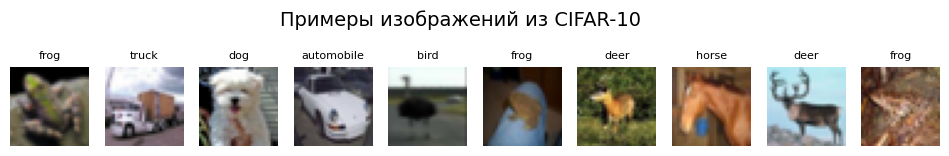

In [10]:
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].numpy()
        img = np.transpose(img, (1, 2, 0))
        img = img * 0.5 + 0.5
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.suptitle("Примеры изображений из CIFAR-10", fontsize=14)
    plt.show()

show_images(train_loader, n=10)

## Модель MLP и цикл обучения

In [13]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = input_dim,
        hidden_dims: tuple = (512, 256, 128),
        num_classes: int = num_classes,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Быстрый sanity-check по форме
model = MLP(input_dim=input_dim, num_classes=num_classes).to(device)
print(model)
print("Обучаемые параметры:", count_params(model))
with torch.no_grad():
    out = model(images.to(device))
print("logits:", out.shape)

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): ReLU()
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)
Обучаемые параметры: 1738890
logits: torch.Size([128, 10])


In [14]:
# вспомогательные функции

# вычисление accuracy по выходам модели
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

# отображение train/val los и acc в виде графиков
def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [15]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [16]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

# Часть A (S08): регуляризация и переобучение

## E1 (base)

MLP побольше (3 скрытых слоя), без Dropout и без BatchNorm.

epoch 01/20 | train loss=1.6744, acc=0.3998 | val loss=1.5558, acc=0.4443
epoch 02/20 | train loss=1.4502, acc=0.4840 | val loss=1.4689, acc=0.4852
epoch 03/20 | train loss=1.3323, acc=0.5289 | val loss=1.3846, acc=0.5167
epoch 04/20 | train loss=1.2392, acc=0.5621 | val loss=1.3804, acc=0.5189
epoch 05/20 | train loss=1.1565, acc=0.5897 | val loss=1.3926, acc=0.5252
epoch 06/20 | train loss=1.0806, acc=0.6170 | val loss=1.3882, acc=0.5279
epoch 07/20 | train loss=0.9970, acc=0.6449 | val loss=1.3678, acc=0.5412
epoch 08/20 | train loss=0.8995, acc=0.6808 | val loss=1.4036, acc=0.5382
epoch 09/20 | train loss=0.8391, acc=0.7005 | val loss=1.4702, acc=0.5415
epoch 10/20 | train loss=0.7509, acc=0.7302 | val loss=1.5848, acc=0.5196
epoch 11/20 | train loss=0.6950, acc=0.7523 | val loss=1.6135, acc=0.5312
epoch 12/20 | train loss=0.6149, acc=0.7804 | val loss=1.6884, acc=0.5431
epoch 13/20 | train loss=0.5559, acc=0.8001 | val loss=1.8207, acc=0.5250
epoch 14/20 | train loss=0.5209, acc=0

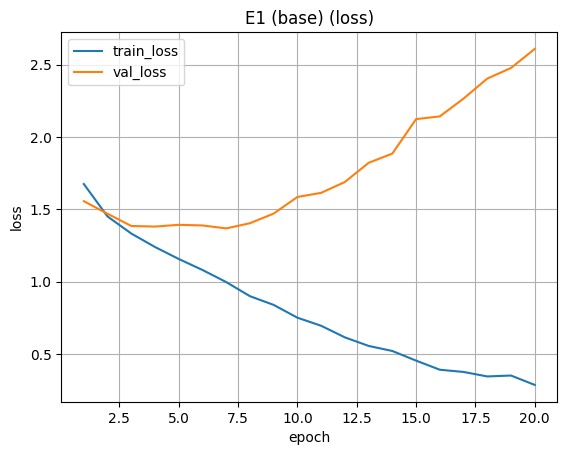

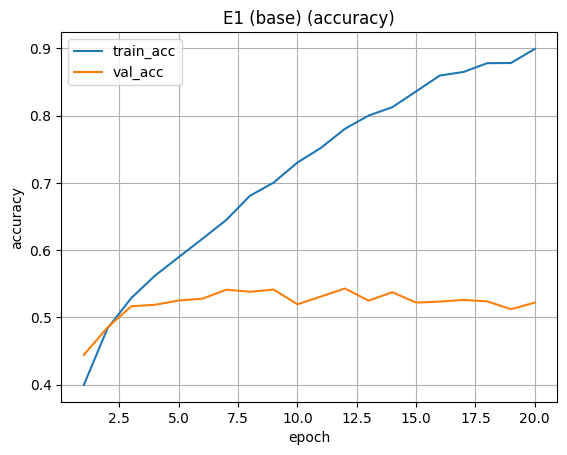

In [19]:
model_e1 = MLP(input_dim=input_dim, num_classes=num_classes, dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_e1.parameters(), lr=1e-3)

history_e1 = fit(
    model_e1, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_e1, title="E1 (base)")

## E2 (Dropout = 0.3)

epoch 01/20 | train loss=1.8101, acc=0.3502 | val loss=1.6155, acc=0.4280
epoch 02/20 | train loss=1.6363, acc=0.4211 | val loss=1.5388, acc=0.4582
epoch 03/20 | train loss=1.5545, acc=0.4499 | val loss=1.4714, acc=0.4863
epoch 04/20 | train loss=1.4937, acc=0.4721 | val loss=1.4489, acc=0.5006
epoch 05/20 | train loss=1.4573, acc=0.4888 | val loss=1.4224, acc=0.5007
epoch 06/20 | train loss=1.4241, acc=0.4972 | val loss=1.4071, acc=0.5023
epoch 07/20 | train loss=1.3866, acc=0.5135 | val loss=1.3912, acc=0.5154
epoch 08/20 | train loss=1.3602, acc=0.5193 | val loss=1.3783, acc=0.5143
epoch 09/20 | train loss=1.3309, acc=0.5279 | val loss=1.3573, acc=0.5270
epoch 10/20 | train loss=1.2989, acc=0.5403 | val loss=1.3683, acc=0.5213
epoch 11/20 | train loss=1.2756, acc=0.5483 | val loss=1.3528, acc=0.5294
epoch 12/20 | train loss=1.2508, acc=0.5528 | val loss=1.3281, acc=0.5426
epoch 13/20 | train loss=1.2366, acc=0.5591 | val loss=1.3570, acc=0.5269
epoch 14/20 | train loss=1.2158, acc=0

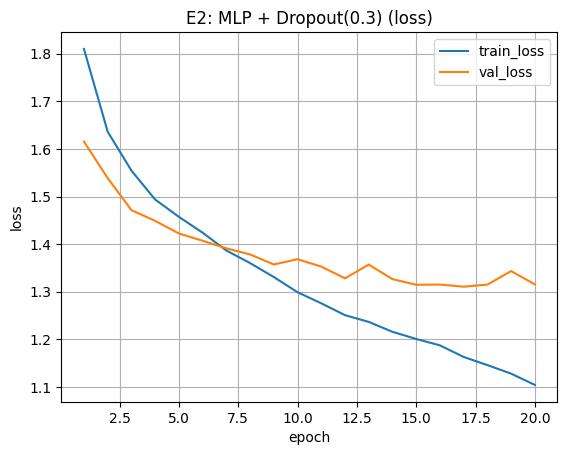

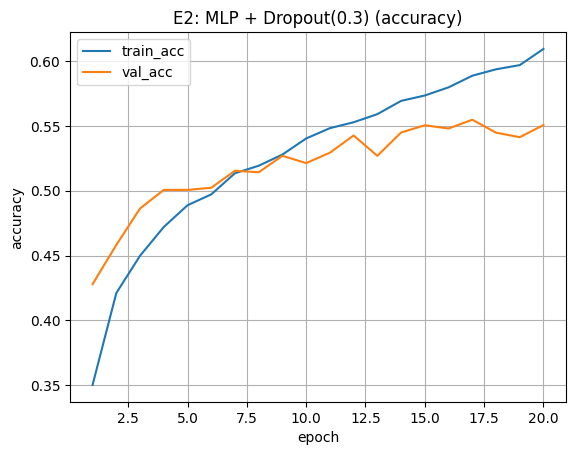

In [23]:
model_e2 = MLP(input_dim=input_dim, num_classes=num_classes, dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_e2.parameters(), lr=1e-3)

history_e2 = fit(
    model_e2, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_e2, title="E2: MLP + Dropout(0.3)")

## E3 (BatchNorm)

epoch 01/20 | train loss=1.6211, acc=0.4199 | val loss=1.5242, acc=0.4528
epoch 02/20 | train loss=1.4170, acc=0.4928 | val loss=1.4037, acc=0.4981
epoch 03/20 | train loss=1.3147, acc=0.5329 | val loss=1.4046, acc=0.5050
epoch 04/20 | train loss=1.2319, acc=0.5626 | val loss=1.3251, acc=0.5385
epoch 05/20 | train loss=1.1615, acc=0.5847 | val loss=1.3178, acc=0.5344
epoch 06/20 | train loss=1.0963, acc=0.6103 | val loss=1.3245, acc=0.5407
epoch 07/20 | train loss=1.0387, acc=0.6295 | val loss=1.3382, acc=0.5317
epoch 08/20 | train loss=0.9860, acc=0.6485 | val loss=1.3209, acc=0.5526
epoch 09/20 | train loss=0.9234, acc=0.6732 | val loss=1.3466, acc=0.5490
epoch 10/20 | train loss=0.8717, acc=0.6891 | val loss=1.3964, acc=0.5381
epoch 11/20 | train loss=0.8075, acc=0.7112 | val loss=1.4298, acc=0.5445
epoch 12/20 | train loss=0.7462, acc=0.7356 | val loss=1.4735, acc=0.5436
epoch 13/20 | train loss=0.7076, acc=0.7487 | val loss=1.5013, acc=0.5345
epoch 14/20 | train loss=0.6556, acc=0

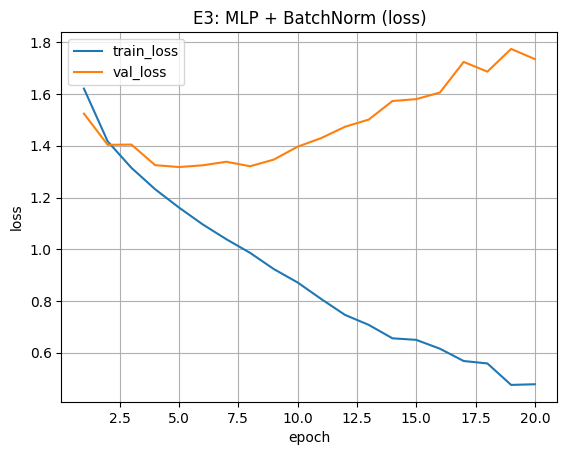

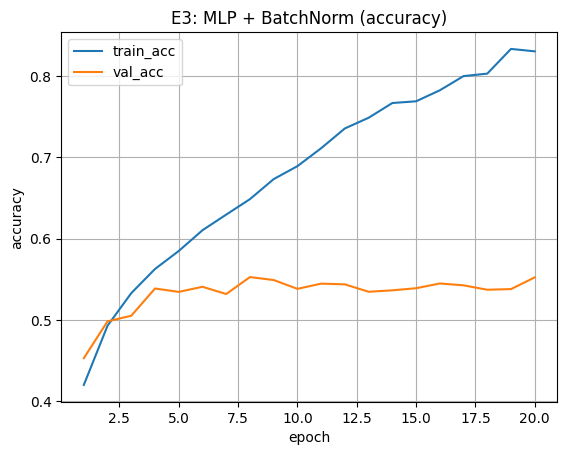

In [24]:
model_e3 = MLP(input_dim=input_dim, num_classes=num_classes, dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_e3.parameters(), lr=1e-3)

history_e3 = fit(
    model_e3, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_e3, title="E3: MLP + BatchNorm")

## E4 (EarlyStopping)

Выбираем **лучший** из (E2/E3) по `val_accuracy`.
Обучаем его с EarlyStopping (patience = 4)

In [22]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

Выбираем лучшую модель по val_accuracy

In [25]:
def get_best_val_accuracy(history):
    return max(history["val_acc"])

# Сравниваем E2 и E3
e2_best_acc = get_best_val_accuracy(history_e2)
e3_best_acc = get_best_val_accuracy(history_e3)

print(f"E2 (Dropout) best val_acc: {e2_best_acc:.4f}")
print(f"E3 (BatchNorm) best val_acc: {e3_best_acc:.4f}")

E2 (Dropout) best val_acc: 0.5548
E3 (BatchNorm) best val_acc: 0.5526


In [30]:
if e2_best_acc > e3_best_acc:
    print("Выбрана модель E2 (Dropout) для E4")
    best_model_config = {
        "input_dim": input_dim,
        "hidden_dims": (512, 256, 128),
        "num_classes": num_classes,
        "activation": "relu",
        "dropout_p": 0.3,
        "use_batchnorm": False
    }
    model_e4 = MLP(**best_model_config).to(device)
    model_e4.load_state_dict(model_e2.state_dict())
else:
    print("Выбрана модель E3 (BatchNorm) для E4")
    best_model_config = {
        "input_dim": input_dim,
        "hidden_dims": (512, 256, 128),
        "num_classes": num_classes,
        "activation": "relu",
        "dropout_p": 0.0,
        "use_batchnorm": True
    }
    model_e4 = MLP(**best_model_config).to(device)
    model_e4.load_state_dict(model_e3.state_dict())

Выбрана модель E2 (Dropout) для E4


epoch 01/50 | train loss=1.0928, acc=0.6129 | val loss=1.3367, acc=0.5462
epoch 02/50 | train loss=1.0784, acc=0.6176 | val loss=1.3256, acc=0.5449
epoch 03/50 | train loss=1.0705, acc=0.6199 | val loss=1.3273, acc=0.5436
epoch 04/50 | train loss=1.0583, acc=0.6243 | val loss=1.3150, acc=0.5510
epoch 05/50 | train loss=1.0343, acc=0.6327 | val loss=1.3190, acc=0.5516
epoch 06/50 | train loss=1.0212, acc=0.6349 | val loss=1.3135, acc=0.5549
epoch 07/50 | train loss=1.0074, acc=0.6435 | val loss=1.3126, acc=0.5549
epoch 08/50 | train loss=1.0097, acc=0.6417 | val loss=1.3211, acc=0.5547
epoch 09/50 | train loss=1.0042, acc=0.6433 | val loss=1.3321, acc=0.5526
epoch 10/50 | train loss=0.9721, acc=0.6583 | val loss=1.3333, acc=0.5480
EarlyStopping: остановка на эпохе 10. Лучший val_acc=0.5549


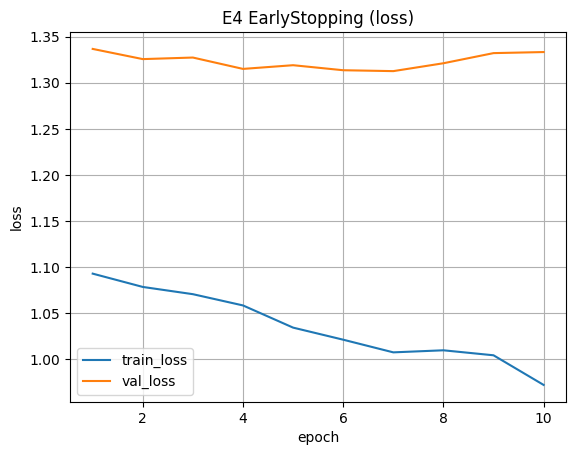

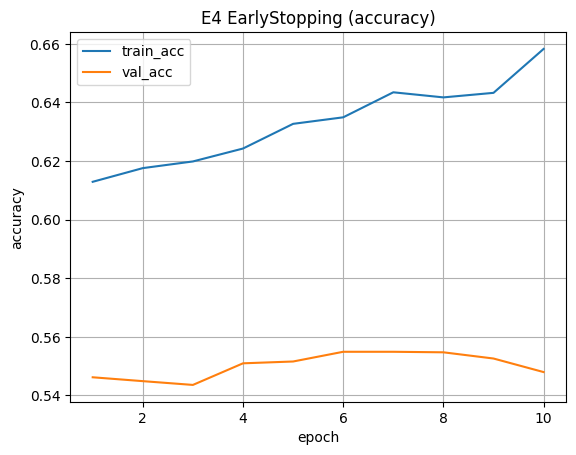

In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_e4.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_e4 = fit(
    model_e4, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50,
    early_stopping=es,
    verbose=True
)

plot_history(history_e4, title="E4 EarlyStopping")

Выбор лучшей модели по val_acc

In [36]:
results = {
    "E1 MLP Base": get_best_val_accuracy(history_e1),
    "E2 MLP+Dropout": get_best_val_accuracy(history_e2),
    "E3 MLP+BatchNorm": get_best_val_accuracy(history_e3),
    "E4 EarlyStopping": get_best_val_accuracy(history_e4),
}

for k, v in results.items():
    print(f"{k:>9}: val_acc={v:.4f}")

E1 MLP Base: val_acc=0.5431
E2 MLP+Dropout: val_acc=0.5548
E3 MLP+BatchNorm: val_acc=0.5526
E4 EarlyStopping: val_acc=0.5549


In [37]:
best_model = model_e4

Проверка лучшей модели на тесте

In [38]:
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"Best model test: loss={test_loss:.4f}, acc={test_acc:.4f}")

Best model test: loss=1.3134, acc=0.5420


## Сохранение конфигурации лучшей модели

In [40]:
from pathlib import Path

artifacts_dir = Path("./artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

best_config = {
    "experiment_id": "E4",
    "dataset": "CIFAR10",
    "seed": SEED,
    "model_config": best_model_config,
    "training_config": {
        "optimizer": "Adam",
        "lr": 1e-3,
        "weight_decay": 0.0,
        "momentum": None,
        "batch_size": batch_size,
        "early_stopping_patience": 4,
        "early_stopping_min_delta": 0.001,
        "max_epochs": 50,
        "epochs_trained": len(history_e4["train_loss"])
    },
    "results": {
        "best_val_accuracy": get_best_val_accuracy(history_e4),
        "best_val_loss": min(history_e4["val_loss"]),
        "test_accuracy": test_acc,
        "test_loss": test_loss,
    }
}

# Сохраняем в JSON
with open(artifacts_dir / "best_config.json", "w") as f:
    json.dump(best_config, f, indent=4)

print(f"Конфиг сохранён в {artifacts_dir / 'best_config.json'}")

Конфиг сохранён в artifacts/best_config.json


In [41]:
# Сохраняем модель
torch.save(model_e4.state_dict(), artifacts_dir / "best_model.pt")

Сохраняем график train/val loss+accuracy для лучшего прогона

График сохранён в artifacts/figures/curves_best.png


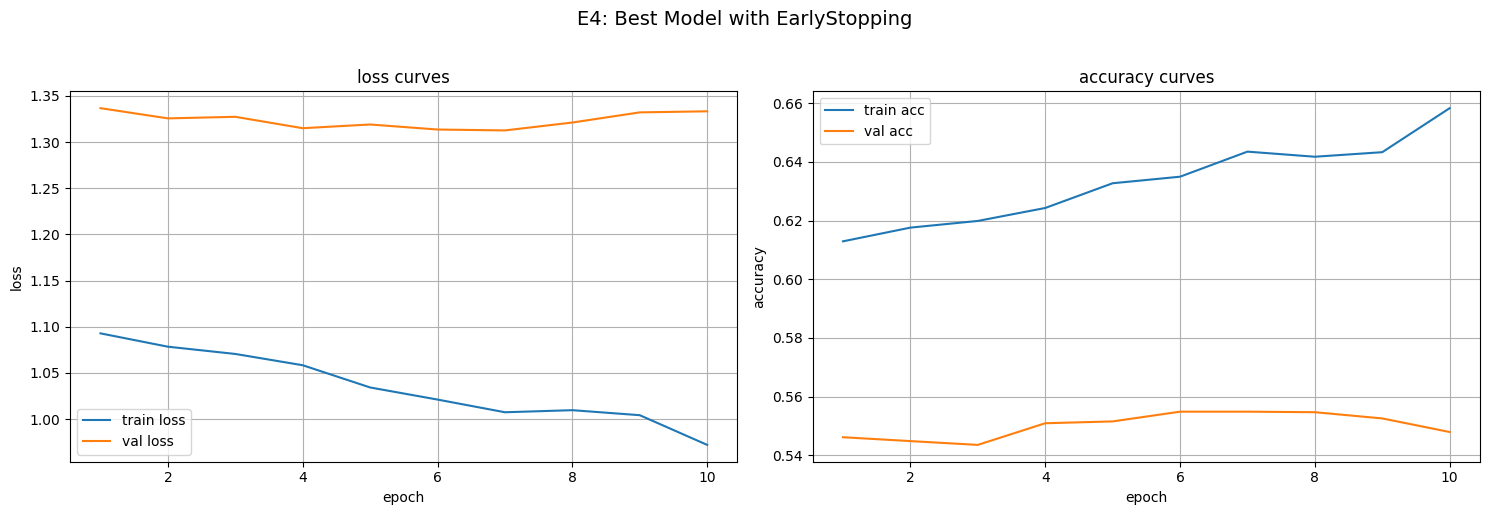

In [44]:
figures_dir = artifacts_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

epochs = np.arange(1, len(history_e4["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График loss
ax1.plot(epochs, history_e4["train_loss"], label='train loss')
ax1.plot(epochs, history_e4["val_loss"], label='val loss')
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss')
ax1.set_title('loss curves')
ax1.legend()
ax1.grid(True)

# График accuracy
ax2.plot(epochs, history_e4["train_acc"], label='train acc')
ax2.plot(epochs, history_e4["val_acc"], label='val acc')
ax2.set_xlabel('epoch')
ax2.set_ylabel('accuracy')
ax2.set_title('accuracy curves')
ax2.legend()
ax2.grid(True)

plt.suptitle('E4: Best Model with EarlyStopping', fontsize=14, y=1.02)
plt.tight_layout()

save_path = figures_dir / "curves_best.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"График сохранён в {save_path}")

plt.show()

# Часть B (S09): LR, оптимизаторы, weight decay

## O1 (LR слишком большой)

epoch 01/8 | train loss=17.8141, acc=0.0982 | val loss=2.3113, acc=0.1015
epoch 02/8 | train loss=2.3654, acc=0.1005 | val loss=2.3109, acc=0.0998
epoch 03/8 | train loss=2.3979, acc=0.1028 | val loss=2.3080, acc=0.0929
epoch 04/8 | train loss=2.3778, acc=0.0984 | val loss=2.3101, acc=0.1040
epoch 05/8 | train loss=2.3679, acc=0.0998 | val loss=2.3071, acc=0.0972
epoch 06/8 | train loss=2.3091, acc=0.0972 | val loss=2.3085, acc=0.0995
epoch 07/8 | train loss=2.3092, acc=0.0997 | val loss=2.3041, acc=0.1017
epoch 08/8 | train loss=2.3086, acc=0.0990 | val loss=2.3090, acc=0.1015


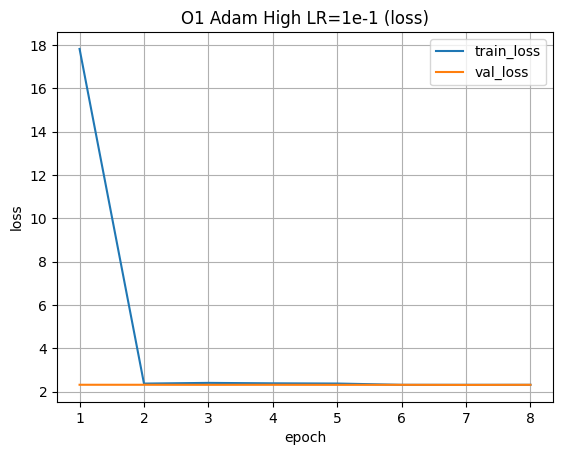

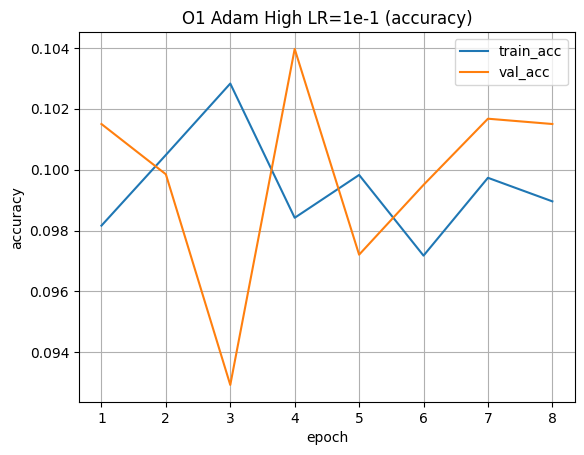

In [57]:
# берем лучшум модель из части А
criterion = nn.CrossEntropyLoss()
EPOCHS = 8
LRO1 = 1e-1 # слишком большой
weight_decay=0.0

model_O1 = MLP(**best_model_config).to(device)

optimizer = optim.Adam(model_O1.parameters(), lr=LRO1, weight_decay=weight_decay)

history_O1 = fit(
    model_O1, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=EPOCHS,
    early_stopping=None
)

plot_history(history_O1, title="O1 Adam High LR=1e-1")

Слишком большой шаг и модель перепрыгивает локальные минимумы

## O2 (LR слишком маленький)

epoch 01/8 | train loss=2.2542, acc=0.1839 | val loss=2.1696, acc=0.2298
epoch 02/8 | train loss=2.1003, acc=0.2511 | val loss=2.0008, acc=0.2935
epoch 03/8 | train loss=1.9804, acc=0.2946 | val loss=1.8947, acc=0.3405
epoch 04/8 | train loss=1.9090, acc=0.3223 | val loss=1.8299, acc=0.3621
epoch 05/8 | train loss=1.8596, acc=0.3356 | val loss=1.7866, acc=0.3769
epoch 06/8 | train loss=1.8256, acc=0.3493 | val loss=1.7553, acc=0.3798
epoch 07/8 | train loss=1.7980, acc=0.3585 | val loss=1.7307, acc=0.3885
epoch 08/8 | train loss=1.7734, acc=0.3677 | val loss=1.7097, acc=0.3928


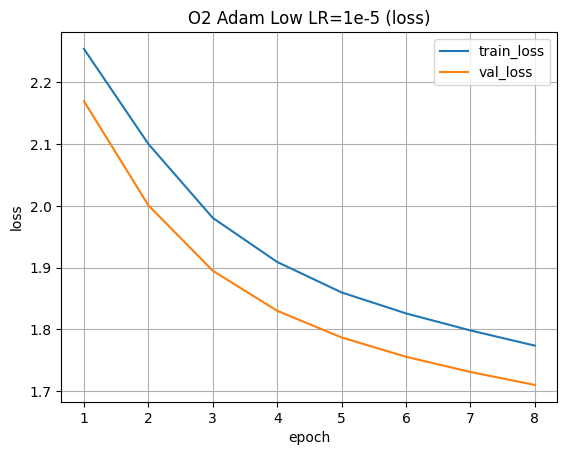

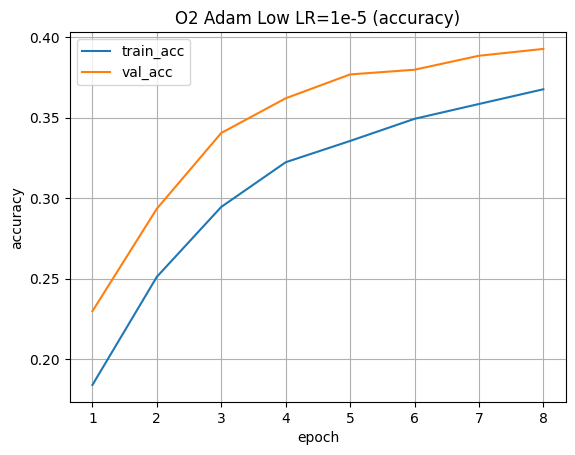

In [58]:
criterion = nn.CrossEntropyLoss()
EPOCHS = 8
LRO2 = 1e-5 # слишком маленький
weight_decay=0.0

model_O2 = MLP(**best_model_config).to(device)

optimizer = optim.Adam(model_O2.parameters(), lr=LRO2, weight_decay=weight_decay)

history_O2 = fit(
    model_O2, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=EPOCHS,
    early_stopping=None
)

plot_history(history_O2, title="O2 Adam Low LR=1e-5")

Модель практически не обучается, очень очень медленно

## O3 (SGD+momentum + weight decay)

epoch 01/13 | train loss=2.0029, acc=0.2677 | val loss=1.7242, acc=0.3827
epoch 02/13 | train loss=1.7075, acc=0.3878 | val loss=1.5881, acc=0.4364
epoch 03/13 | train loss=1.6100, acc=0.4276 | val loss=1.5102, acc=0.4706
epoch 04/13 | train loss=1.5347, acc=0.4562 | val loss=1.4651, acc=0.4792
epoch 05/13 | train loss=1.4749, acc=0.4764 | val loss=1.4339, acc=0.4911
epoch 06/13 | train loss=1.4281, acc=0.4937 | val loss=1.3787, acc=0.5146
epoch 07/13 | train loss=1.3913, acc=0.5081 | val loss=1.3720, acc=0.5160
epoch 08/13 | train loss=1.3621, acc=0.5178 | val loss=1.3520, acc=0.5211
epoch 09/13 | train loss=1.3250, acc=0.5275 | val loss=1.3413, acc=0.5215
epoch 10/13 | train loss=1.2866, acc=0.5444 | val loss=1.3162, acc=0.5340
epoch 11/13 | train loss=1.2591, acc=0.5530 | val loss=1.3396, acc=0.5303
epoch 12/13 | train loss=1.2265, acc=0.5626 | val loss=1.3102, acc=0.5428
epoch 13/13 | train loss=1.2164, acc=0.5675 | val loss=1.3339, acc=0.5273


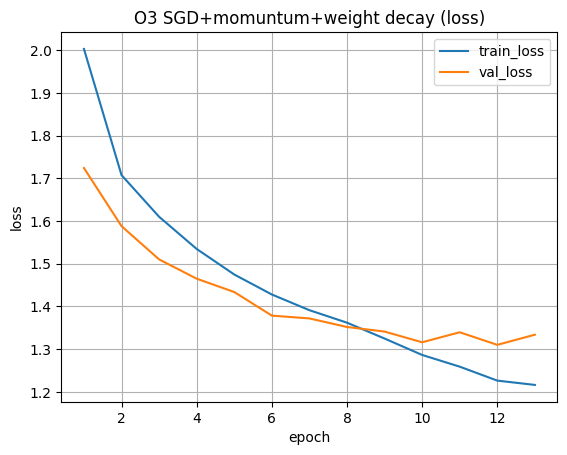

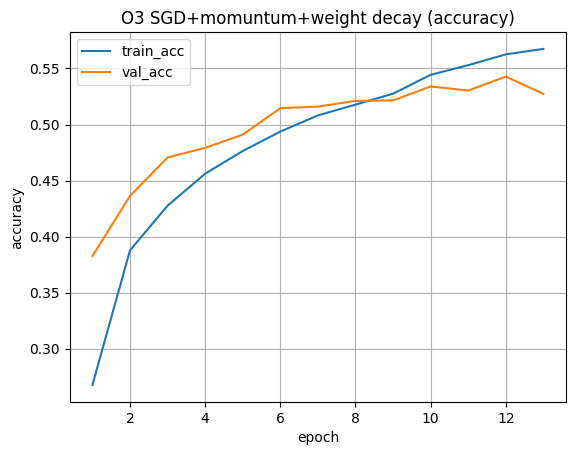

In [59]:
criterion = nn.CrossEntropyLoss()
EPOCHS = 13
# параметры для SGD
LRO3 = 1e-2
weight_decay=1e-4
momentum = 0.9


model_O3 = MLP(**best_model_config).to(device)

optimizer = optim.SGD(model_O3.parameters(), lr=LRO3, momentum=momentum, weight_decay=weight_decay)

history_O3 = fit(
    model_O3, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=EPOCHS,
    early_stopping=None
)

plot_history(history_O3, title="O3 SGD+momuntum+weight decay")

## Сохранение результатов экспериментов E1-E4 и 01-03

In [63]:
def create_experiment_row(exp_id, model, history, config_desc,
                          optimizer_name="Adam", lr=1e-3,
                          weight_decay=0.0, momentum=None):

    # Получаем лучшие значения
    best_val_acc = max(history["val_acc"])
    best_val_loss = min(history["val_loss"])
    epochs_trained = len(history["train_loss"])

    return {
        "experiment_id": exp_id,
        "dataset": "CIFAR10",
        "seed": SEED,
        "model_summary": config_desc,
        "optimizer": optimizer_name,
        "lr": lr,
        "momentum": momentum if momentum is not None else "",
        "weight_decay": weight_decay,
        "epochs_trained": epochs_trained,
        "best_val_accuracy": round(best_val_acc, 6),
        "best_val_loss": round(best_val_loss, 6)
    }


# Описания моделей
e1_desc = "MLP [512,256,128], ReLU, no dropout, no batchnorm"
e2_desc = "MLP [512,256,128], ReLU, dropout=0.3, no batchnorm"
e3_desc = "MLP [512,256,128], ReLU, no dropout, batchnorm=True"
e4_desc = f"MLP [512,256,128], ReLU, dropout={best_model_config['dropout_p']}, batchnorm={best_model_config['use_batchnorm']}"
o1_desc = f"MLP [512,256,128], ReLU, dropout={best_model_config['dropout_p']}, batchnorm={best_model_config['use_batchnorm']}"
o2_desc = f"MLP [512,256,128], ReLU, dropout={best_model_config['dropout_p']}, batchnorm={best_model_config['use_batchnorm']}"
o3_desc = f"MLP [512,256,128], ReLU, dropout={best_model_config['dropout_p']}, batchnorm={best_model_config['use_batchnorm']}"
# Создаем DataFrame с результатами
results = [
    create_experiment_row("E1", model_e1, history_e1, e1_desc),
    create_experiment_row("E2", model_e2, history_e2, e2_desc),
    create_experiment_row("E3", model_e3, history_e3, e3_desc),
    create_experiment_row("E4", model_e4, history_e4, e4_desc),
    create_experiment_row("O1", model_O1, history_O1, o1_desc,
    optimizer_name="Adam", lr=1e-1, weight_decay=0.0, momentum=None),
    create_experiment_row("O2", model_O2, history_O2, o2_desc,
        optimizer_name="Adam", lr=1e-5, weight_decay=0.0, momentum=None),
    create_experiment_row("O3", model_O3, history_O3, o3_desc,
        optimizer_name="SGD", lr=1e-2, weight_decay=1e-4, momentum=0.9)
]

df_results = pd.DataFrame(results)
print(df_results.to_string())

df_results.to_csv(artifacts_dir / "runs.csv", index=False)
print(f"\nРезультаты сохранены в {artifacts_dir / 'runs.csv'}")

  experiment_id  dataset  seed                                          model_summary optimizer       lr momentum  weight_decay  epochs_trained  best_val_accuracy  best_val_loss
0            E1  CIFAR10    42      MLP [512,256,128], ReLU, no dropout, no batchnorm      Adam  0.00100                 0.0000              20           0.543077       1.367794
1            E2  CIFAR10    42     MLP [512,256,128], ReLU, dropout=0.3, no batchnorm      Adam  0.00100                 0.0000              20           0.554778       1.310620
2            E3  CIFAR10    42    MLP [512,256,128], ReLU, no dropout, batchnorm=True      Adam  0.00100                 0.0000              20           0.552604       1.317805
3            E4  CIFAR10    42  MLP [512,256,128], ReLU, dropout=0.3, batchnorm=False      Adam  0.00100                 0.0000              10           0.554904       1.312581
4            O1  CIFAR10    42  MLP [512,256,128], ReLU, dropout=0.3, batchnorm=False      Adam  0.10000      

Сохраняем график, показывающий поведение O1 и O2 (LR слишком большой/маленький)

График сохранён в artifacts/figures/curves_lr_extremes.png


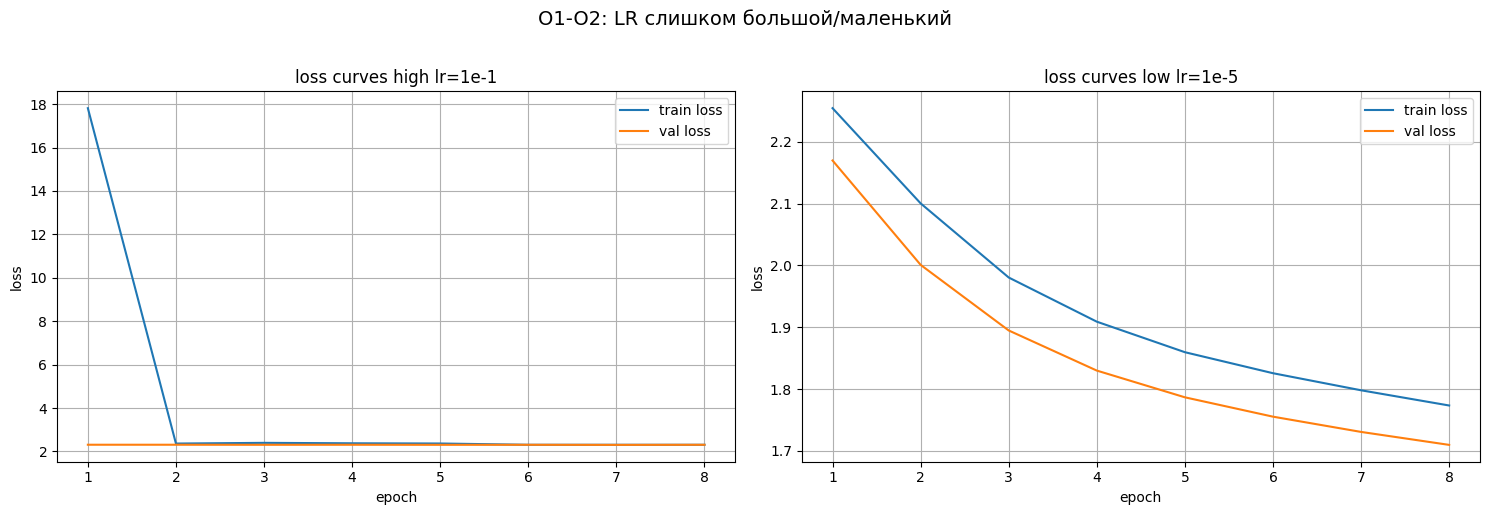

In [66]:
epochsO1 = np.arange(1, len(history_O1["train_loss"]) + 1)
epochsO2 = np.arange(1, len(history_O2["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График loss
ax1.plot(epochsO1, history_O1["train_loss"], label='train loss')
ax1.plot(epochsO1, history_O1["val_loss"], label='val loss')
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss')
ax1.set_title('loss curves high lr=1e-1')
ax1.legend()
ax1.grid(True)

# График accuracy
ax2.plot(epochsO2, history_O2["train_loss"], label='train loss')
ax2.plot(epochsO2, history_O2["val_loss"], label='val loss')
ax2.set_xlabel('epoch')
ax2.set_ylabel('loss')
ax2.set_title('loss curves low lr=1e-5')
ax2.legend()
ax2.grid(True)

plt.suptitle('O1-O2: LR слишком большой/маленький', fontsize=14, y=1.02)
plt.tight_layout()

save_path = figures_dir / "curves_lr_extremes.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"График сохранён в {save_path}")

plt.show()